In [1]:
# Mengimpor pustaka (libraries) yang dibutuhkan untuk analisis data dan visualisasi
import pandas as pd              # Pustaka utama untuk manipulasi dan analisis data tabular (DataFrame)
import numpy as np               # Pustaka untuk komputasi numerik dan operasi array
import matplotlib.pyplot as plt  # Modul visualisasi data dasar untuk membuat grafik dan plot
import seaborn as sns           # Pustaka visualisasi statistik berbasis matplotlib dengan tampilan modern


In [2]:
# Membaca dataset pinjaman (loan data) periode 2007-2014 dari file CSV ke dalam DataFrame pandas
# Parameter low_memory=False digunakan agar pandas memproses seluruh kolom tanpa membatasi tipe data campuran pada file besar
df = pd.read_csv('loan_data_2007_2014.csv', low_memory=False)


In [3]:
# Menampilkan dimensi dataset (jumlah baris dan kolom)
print("Jumlah Baris dan Kolom:", df.shape)

# Menampilkan informasi detail struktur dataset: nama kolom, jumlah nilai non-null, dan tipe data tiap kolom
print("\nInformasi Tipe Data:")
df.info()


Jumlah Baris dan Kolom: (466285, 75)

Informasi Tipe Data:


<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  str    
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  str    
 10  sub_grade                    466285 non-null  str    
 11  emp_title                    438697 non-null  str    
 12  emp_length                   445277 non-null  str    
 13  home_owner

In [4]:
# Menghitung total nilai kosong (missing values / NaN) per kolom lalu mengurutkannya secara menurun
missing_values = df.isnull().sum().sort_values(ascending=False)

# Menghitung persentase missing values terhadap total seluruh baris data
missing_percentage = (missing_values / len(df)) * 100

# Menampilkan 10 kolom dengan persentase missing values tertinggi
print("\nTop 10 Kolom dengan Missing Value Terbanyak (%):")
print(missing_percentage.head(10))



Top 10 Kolom dengan Missing Value Terbanyak (%):
max_bal_bc            100.0
open_rv_24m           100.0
inq_fi                100.0
open_rv_12m           100.0
il_util               100.0
mths_since_rcnt_il    100.0
total_bal_il          100.0
open_il_24m           100.0
open_il_12m           100.0
open_il_6m            100.0
dtype: float64


In [5]:
# Menghitung dan menampilkan frekuensi kemunculan setiap kategori status pinjaman pada kolom 'loan_status'
print("\nDistribusi Nilai pada Kolom loan_status:")
print(df['loan_status'].value_counts())



Distribusi Nilai pada Kolom loan_status:
loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64


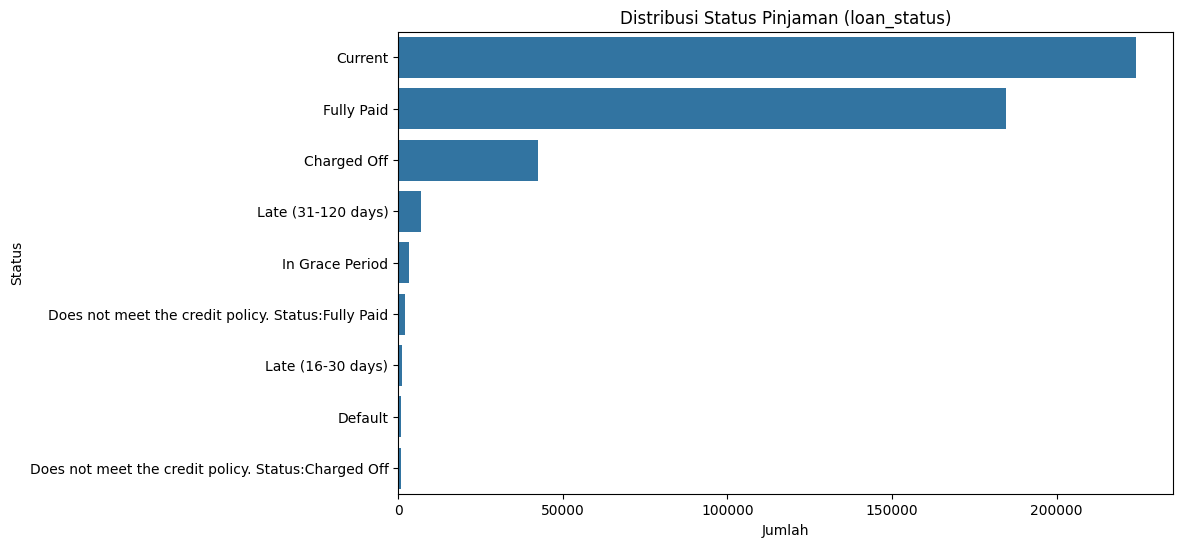

In [6]:
# Mengatur ukuran kanvas grafik (lebar 10 inci, tinggi 6 inci)
plt.figure(figsize=(10, 6))

# Membuat diagram batang horizontal (countplot) distribusi status pinjaman, diurutkan dari frekuensi terbanyak
sns.countplot(y='loan_status', data=df, order=df['loan_status'].value_counts().index)

# Menambahkan judul grafik dan label keterangan pada sumbu X dan Y
plt.title('Distribusi Status Pinjaman (loan_status)')
plt.xlabel('Jumlah')
plt.ylabel('Status')

# Menampilkan visualisasi plot ke layar
plt.show()


In [7]:
# Memfilter dataset: membuang pinjaman dengan status 'Current' karena pinjaman masih berjalan dan belum selesai hasilnya
# Menggunakan .copy() untuk membuat salinan DataFrame baru secara independen di memori
df_clean = df[df['loan_status'] != 'Current'].copy()


In [8]:
# Mendefinisikan daftar kategori status pinjaman yang diklasifikasikan sebagai pinjaman bermasalah / gagal bayar (Bad Loan)
bad_status = [
    'Charged Off', 
    'Default', 
    'Does not meet the credit policy. Status:Charged Off',
    'Late (31-120 days)'
]


In [9]:
# Membuat kolom target biner: 0 untuk pinjaman berisiko/gagal bayar (Bad), 1 untuk pinjaman lancar (Good)
# Menggunakan np.where: jika loan_status masuk dalam bad_status bernilai 0, jika tidak bernilai 1
df_clean['target'] = np.where(df_clean['loan_status'].isin(bad_status), 0, 1)


In [10]:
# Memeriksa hasil pelabelan dan distribusi kelas target (1 = Good Loan, 0 = Bad Loan)
print("Distribusi Target (1 = Good, 0 = Bad):")
print(df_clean['target'].value_counts())


Distribusi Target (1 = Good, 0 = Bad):
target
1    191091
0     50968
Name: count, dtype: int64


In [11]:
# Menghapus kolom asli 'loan_status' karena sudah ditransformasikan menjadi kolom 'target' (mencegah data leakage)
df_clean = df_clean.drop('loan_status', axis=1)


In [12]:
# Mendefinisikan daftar kolom yang harus dibuang dari dataset:
# 1. Identifier unik & URL yang tidak memiliki nilai prediktif ('id', 'member_id', 'url', 'Unnamed: 0')
# 2. Teks bebas berkardinalitas tinggi dan tanggal ('desc', 'zip_code', 'emp_title', 'title', 'issue_d', 'earliest_cr_line')
# 3. Fitur bernilai konstan / tidak memiliki variasi informasi ('policy_code', 'application_type')
# 4. Fitur pasca-pinjaman (Data Leakage) yang mencatat riwayat setelah pinjaman disetujui / berjalan
cols_to_drop = [
    'Unnamed: 0', 'id', 'member_id', 'url', 'desc', 'zip_code', 
    'emp_title', 'title', 'issue_d', 'earliest_cr_line', # teks kardinalitas tinggi & tanggal
    'policy_code', 'application_type', # kolom bernilai konstan
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 
    'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d'
]


In [13]:
# Memastikan hanya kolom yang benar-benar ada di dalam DataFrame yang akan dihapus
cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]

# Menghapus kolom-kolom yang tidak relevan tersebut dari DataFrame
df_clean = df_clean.drop(columns=cols_to_drop)


In [14]:
# Menghitung persentase missing values pada setiap kolom yang tersisa di DataFrame
missing_perc = df_clean.isnull().mean() * 100


In [15]:
# Mengidentifikasi dan mengumpulkan kolom-kolom yang memiliki missing values lebih dari 50%
cols_high_missing = missing_perc[missing_perc > 50].index.tolist()

# Menampilkan jumlah dan daftar nama kolom dengan missing values > 50%
print(f"\nMenghapus {len(cols_high_missing)} kolom dengan missing value > 50%:")
print(cols_high_missing)



Menghapus 20 kolom dengan missing value > 50%:
['mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m']


In [16]:
# Menghapus kolom-kolom dengan missing values tinggi (> 50%) dari DataFrame
df_clean = df_clean.drop(columns=cols_high_missing)

# Menampilkan dimensi data terbaru setelah tahap pembersihan fitur selesai
print("\nShape data setelah pembersihan awal:", df_clean.shape)



Shape data setelah pembersihan awal: (242059, 30)


In [17]:
# Mengatur ukuran figure kanvas visualisasi matriks korelasi (lebar 15 inci, tinggi 10 inci)
plt.figure(figsize=(15, 10))


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [18]:
# Mengambil hanya kolom bertipe data numerik untuk perhitungan korelasi
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

# Menghitung matriks korelasi Pearson antar variabel numerik
correlation_matrix = df_clean[numeric_cols].corr()


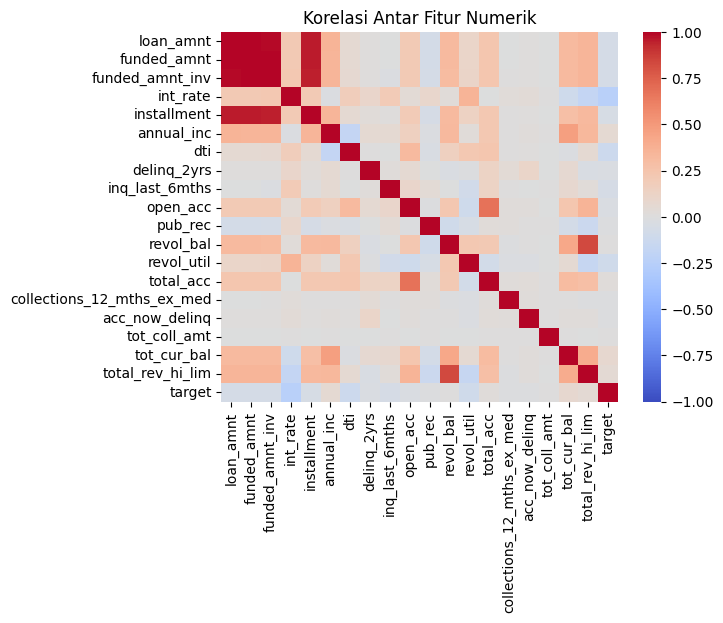

In [19]:
# Membuat visualisasi Heatmap korelasi dengan skema warna 'coolwarm' dan rentang nilai -1 sampai 1
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

# Memberikan judul pada visualisasi Heatmap
plt.title('Korelasi Antar Fitur Numerik')

# Menampilkan grafik heatmap ke layar
plt.show()


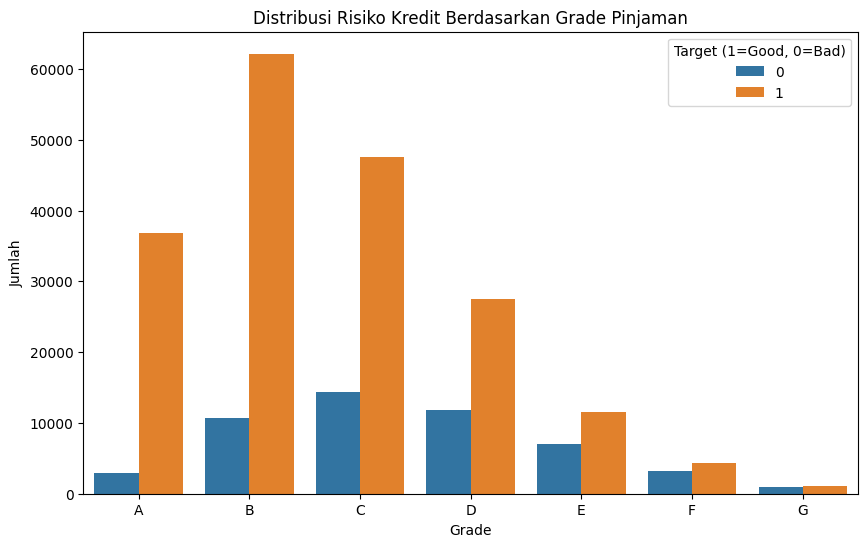

In [20]:
# Analisis Bivariat: Melihat pengaruh Grade Pinjaman ('grade') terhadap Target Risiko Kredit ('target')
# Mengatur ukuran kanvas visualisasi
plt.figure(figsize=(10, 6))

# Membuat diagram batang bertingkat (countplot) untuk setiap grade yang diurutkan secara alfabetis
sns.countplot(x='grade', hue='target', data=df_clean, order=sorted(df_clean['grade'].dropna().unique()))

# Memberikan judul grafik dan label keterangan sumbu
plt.title('Distribusi Risiko Kredit Berdasarkan Grade Pinjaman')
plt.xlabel('Grade')
plt.ylabel('Jumlah')

# Menambahkan legenda penjelas kelas target (1 = Good, 0 = Bad)
plt.legend(title='Target (1=Good, 0=Bad)')

# Menampilkan plot ke layar
plt.show()


In [21]:
# Mengimpor modul split data untuk membagi dataset menjadi data training dan data testing
from sklearn.model_selection import train_test_split

# Mengimpor modul StandardScaler untuk melakukan standardisasi fitur numerik (mean=0, std=1)
from sklearn.preprocessing import StandardScaler


In [22]:
# Memisahkan nama-nama kolom bertipe kategorikal (object / string)
cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns

# Memisahkan nama-nama kolom bertipe numerik (integer / float)
num_cols = df_clean.select_dtypes(include=[np.number]).columns


In [23]:
# Imputasi Missing Values Numerik: Mengisi nilai kosong pada kolom numerik dengan nilai Median (tahan terhadap outlier)
for col in num_cols:
    # Memeriksa jika kolom bukan variabel target dan masih mengandung missing value
    if col != 'target' and df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())


In [24]:
# Imputasi Missing Values Kategorikal: Mengisi nilai kosong pada kolom kategorikal dengan Modus (nilai yang paling sering muncul)
for col in cat_cols:
    # Memeriksa jika kolom kategorikal masih mengandung missing value
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


In [25]:
# Mengubah data teks kategorikal menjadi representasi angka menggunakan One-Hot Encoding
# Parameter drop_first=True digunakan untuk membuang 1 kolom dummy pertama guna menghindari dummy variable trap (multikolinearitas sempurna)
# Parameter dtype=np.uint8 digunakan untuk mengoptimalkan efisiensi memori RAM
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True, dtype=np.uint8)

# Menampilkan dimensi DataFrame hasil encoding dan total estimasi penggunaan memori RAM
print("Shape df_encoded:", df_encoded.shape)
print("Memory usage:", round(df_encoded.memory_usage().sum() / (1024**2), 2), "MB")


Shape df_encoded: (242059, 142)
Memory usage: 66.95 MB


In [26]:
# Memisahkan matriks fitur independen (X) dan vektor label dependen (y)
X = df_encoded.drop('target', axis=1)  # Menghapus kolom target untuk mendapatkan fitur input X
y = df_encoded['target']              # Mengambil kolom target sebagai label output y

# Menampilkan dimensi fitur X dan target y
print("Dimensi X:", X.shape)
print("Dimensi y:", y.shape)


Dimensi X: (242059, 141)
Dimensi y: (242059,)


In [27]:
# Membagi dataset menjadi Data Latih / Training (80%) dan Data Uji / Testing (20%)
# test_size=0.2    : 20% data dialokasikan untuk evaluasi pengujian
# random_state=42  : Memastikan pembagian data konsisten dan dapat direproduksi ulang
# stratify=y       : Menjaga rasio proporsi kelas target (Good vs Bad) tetap seimbang pada data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Menampilkan dimensi data latih dan data uji yang telah dibagi
print("Dimensi X_train:", X_train.shape)
print("Dimensi X_test:", X_test.shape)


Dimensi X_train: (193647, 141)
Dimensi X_test: (48412, 141)


In [28]:
# Menginisialisasi objek StandardScaler untuk menstandarisasi skala fitur numerik agar seragam
scaler = StandardScaler()


In [29]:
# Melakukan proses fit dan transform pada data latih (menghitung mean & std sekaligus mentransformasikan data latih)
X_train_scaled = scaler.fit_transform(X_train)

# Melakukan transform saja pada data uji menggunakan parameter mean & std dari data latih (mencegah data leakage)
X_test_scaled = scaler.transform(X_test)

# Menampilkan konfirmasi penyelesaian tahap data preparation beserta dimensi array hasil scaling
print("Data Preparation Selesai!")
print(f"Dimensi X_train: {X_train_scaled.shape}")
print(f"Dimensi X_test: {X_test_scaled.shape}")


Data Preparation Selesai!
Dimensi X_train: (193647, 141)
Dimensi X_test: (48412, 141)


## 4. Data Modelling
Pada tahap ini, kita membangun dan melatih 2 algoritma machine learning:
1. **Logistic Regression** (Algoritma wajib - Linear Model)
2. **Random Forest Classifier** (Algoritma pembanding - Tree-based Ensemble)

Hyperparameter tuning dilakukan menggunakan **Cross-Validation** untuk mendapatkan kombinasi parameter terbaik.

In [30]:
# 1. Modelling: Logistic Regression dengan Hyperparameter Tuning
# Mengimpor model Logistic Regression dari sklearn
from sklearn.linear_model import LogisticRegression
# Mengimpor modul pencarian hyperparameter acak (RandomizedSearchCV) dan stratified cross-validation
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

print("=== Pelatihan Model 1: Logistic Regression ===")

# Mendefinisikan ruang hyperparameter yang akan diuji pada model Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0],          # Parameter kekuatan regularisasi (invers regularisasi)
    'class_weight': ['balanced', None],   # Penanganan ketidakseimbangan kelas target
    'max_iter': [1000],                   # Batas maksimum iterasi solver untuk konvergensi
    'solver': ['lbfgs']                   # Algoritma optimasi solver standar untuk regresi logistik
}

# Mengonfigurasi cross-validation 3-fold berstrata dengan pengacakan data
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Menginisialisasi RandomizedSearchCV untuk mencari kombinasi parameter terbaik berdasarkan metrik ROC-AUC
rs_lr = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_distributions=param_grid_lr,
    n_iter=4,             # Jumlah kombinasi parameter yang dicoba secara acak
    cv=cv,                # Skema validasi silang (cross-validation)
    scoring='roc_auc',    # Metrik utama optimasi performa model
    random_state=42,      # Menjamin hasil tuning dapat direproduksi
    n_jobs=-1             # Memanfaatkan seluruh core CPU untuk mempercepat proses komputasi paralel
)

# Menjalankan tuning hyperparameter pada subset 30.000 data latih untuk efisiensi waktu komputasi
rs_lr.fit(X_train_scaled[:30000], y_train.iloc[:30000])

# Mengambil estimator model terbaik hasil tuning dan melatihnya kembali pada seluruh data latih (X_train_scaled)
best_lr = rs_lr.best_estimator_
best_lr.fit(X_train_scaled, y_train)

# Menampilkan kombinasi parameter terbaik dan skor validasi silang (CV ROC-AUC) terbaik
print(f"Hyperparameter Terbaik Logistic Regression: {rs_lr.best_params_}")
print(f"Best CV ROC-AUC Score: {rs_lr.best_score_:.4f}")


=== Pelatihan Model 1: Logistic Regression ===


Hyperparameter Terbaik Logistic Regression: {'solver': 'lbfgs', 'max_iter': 1000, 'class_weight': None, 'C': 1.0}
Best CV ROC-AUC Score: 0.6969


In [31]:
# 2. Modelling: Random Forest Classifier dengan Hyperparameter Tuning
# Mengimpor algoritma ensemble Random Forest Classifier dari sklearn
from sklearn.ensemble import RandomForestClassifier

print("=== Pelatihan Model 2: Random Forest Classifier ===")

# Mendefinisikan ruang hyperparameter untuk dieksplorasi pada model Random Forest
param_grid_rf = {
    'n_estimators': [100, 150],           # Jumlah pohon keputusan (decision trees) di dalam ensemble
    'max_depth': [10, 15],                # Kedalaman maksimum setiap pohon untuk mencegah overfitting
    'min_samples_split': [10, 20],        # Jumlah sampel minimum yang diperlukan untuk membelah simpul internal
    'class_weight': ['balanced', None],   # Penyesuaian bobot kelas untuk menangani ketidakseimbangan data
    'random_state': [42]                  # Menjaga konsistensi pembentukan pohon
}

# Menginisialisasi RandomizedSearchCV untuk model Random Forest
rs_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_grid_rf,
    n_iter=4,             # Jumlah kombinasi kandidat parameter yang diuji
    cv=cv,                # Skema Stratified K-Fold cross-validation 3-fold
    scoring='roc_auc',    # Menggunakan ROC-AUC sebagai acuan pemilihan model terbaik
    random_state=42,      # Reproducibility
    n_jobs=-1             # Eksekusi paralel multi-core
)

# Melakukan tuning hyperparameter pada subset 30.000 sampel data latih
rs_rf.fit(X_train_scaled[:30000], y_train.iloc[:30000])

# Mengambil model Random Forest terbaik hasil tuning dan melatihnya pada keseluruhan data latih (X_train_scaled)
best_rf = rs_rf.best_estimator_
best_rf.fit(X_train_scaled, y_train)

# Menampilkan hasil parameter terbaik dan skor validasi silang (CV ROC-AUC)
print(f"Hyperparameter Terbaik Random Forest: {rs_rf.best_params_}")
print(f"Best CV ROC-AUC Score: {rs_rf.best_score_:.4f}")


=== Pelatihan Model 2: Random Forest Classifier ===


Hyperparameter Terbaik Random Forest: {'random_state': 42, 'n_estimators': 100, 'min_samples_split': 20, 'max_depth': 15, 'class_weight': None}
Best CV ROC-AUC Score: 0.6996


## 5. Model Evaluation
Evaluasi performa model dilakukan pada data uji (`X_test_scaled`) menggunakan metrik:
- **Accuracy, Precision, Recall, F1-Score, dan ROC-AUC**
- **Confusion Matrix**
- **Kurva ROC (Receiver Operating Characteristic)**

In [32]:
# Evaluasi Kinerja Model pada Data Uji (X_test_scaled)
# Mengimpor metrik-metrik evaluasi klasifikasi dari sklearn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Melakukan prediksi label kelas biner (0 atau 1) dan probabilitas kelas positif (1/Good) untuk Logistic Regression
y_pred_lr = best_lr.predict(X_test_scaled)
y_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

# Melakukan prediksi label kelas biner dan probabilitas kelas positif (1/Good) untuk Random Forest
y_pred_rf = best_rf.predict(X_test_scaled)
y_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

# Menyusun ringkasan seluruh metrik evaluasi ke dalam bentuk DataFrame perbandingan
metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_proba_lr)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

# Menampilkan tabel perbandingan metrik evaluasi dengan format 4 desimal di belakang koma
print("==================== TABEL PERBANDINGAN METRIK EVALUASI ====================")
display(metrics_comparison.style.format({'Logistic Regression': '{:.4f}', 'Random Forest': '{:.4f}'}))

# Menampilkan classification report detail (Precision, Recall, F1-Score per kelas) untuk Logistic Regression
print("\n--- Classification Report: Logistic Regression ---")
print(classification_report(y_test, y_pred_lr, target_names=['Bad (0)', 'Good (1)']))

# Menampilkan classification report detail untuk Random Forest
print("\n--- Classification Report: Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=['Bad (0)', 'Good (1)']))


==================== TABEL PERBANDINGAN METRIK EVALUASI ====================


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.7911,0.7900
1,Precision,0.7969,0.7921
2,Recall,0.9869,0.9952
3,F1-Score,0.8818,0.8821
4,ROC-AUC,0.7010,0.7013



--- Classification Report: Logistic Regression ---
              precision    recall  f1-score   support

     Bad (0)       0.54      0.06      0.10     10194
    Good (1)       0.80      0.99      0.88     38218

    accuracy                           0.79     48412
   macro avg       0.67      0.52      0.49     48412
weighted avg       0.74      0.79      0.72     48412


--- Classification Report: Random Forest ---
              precision    recall  f1-score   support

     Bad (0)       0.54      0.02      0.04     10194
    Good (1)       0.79      1.00      0.88     38218

    accuracy                           0.79     48412
   macro avg       0.66      0.51      0.46     48412
weighted avg       0.74      0.79      0.70     48412



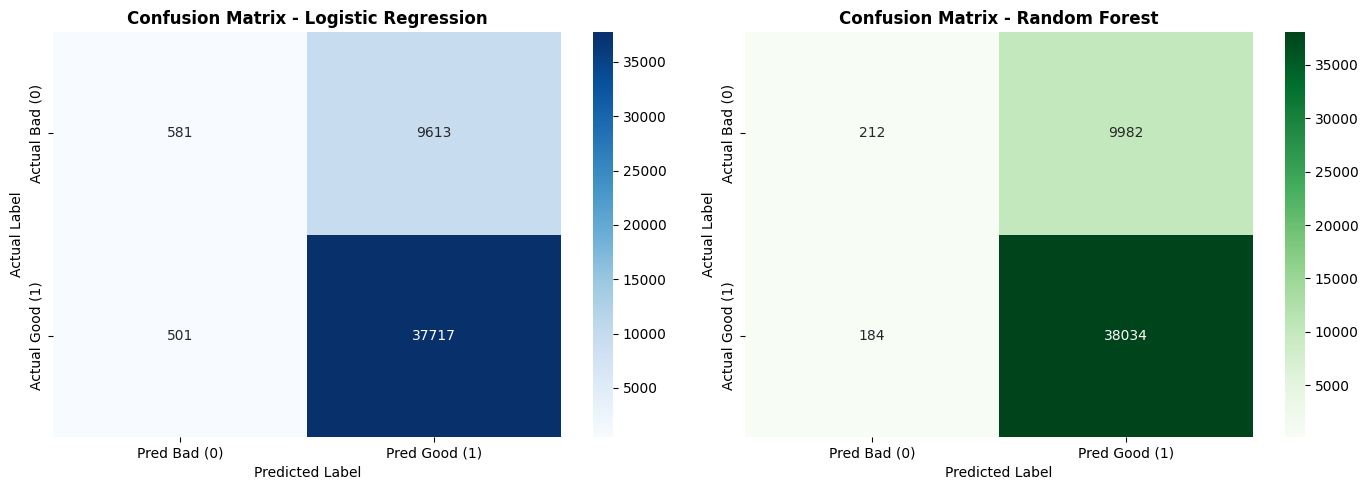

In [33]:
# Visualisasi Perbandingan Confusion Matrix untuk kedua model
# Membuat subplot berdampingan 1 baris 2 kolom dengan ukuran kanvas 14 x 5 inci
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Menghitung dan memvisualisasikan Confusion Matrix untuk Logistic Regression (skema warna Biru)
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Bad (0)', 'Pred Good (1)'],
            yticklabels=['Actual Bad (0)', 'Actual Good (1)'])
axes[0].set_title('Confusion Matrix - Logistic Regression', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# 2. Menghitung dan memvisualisasikan Confusion Matrix untuk Random Forest (skema warna Hijau)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Pred Bad (0)', 'Pred Good (1)'],
            yticklabels=['Actual Bad (0)', 'Actual Good (1)'])
axes[1].set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

# Menata tata letak subplot agar rapi dan tidak saling tumpang tindih
plt.tight_layout()
# Menampilkan visualisasi plot ke layar
plt.show()


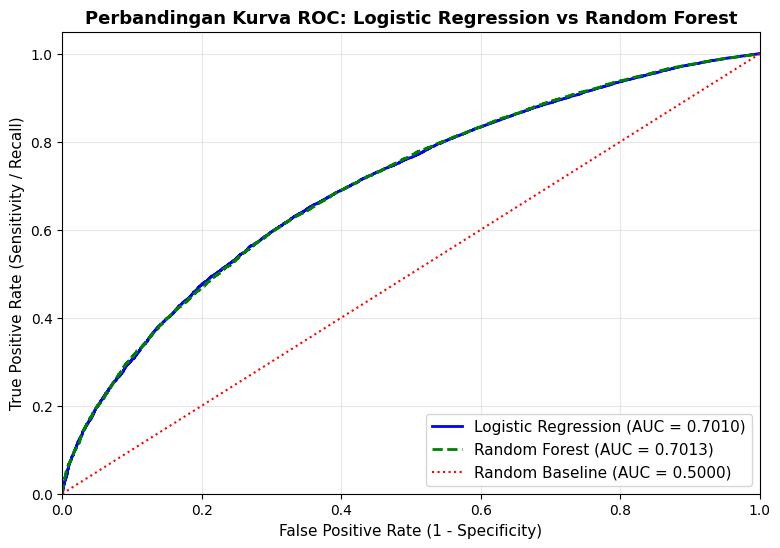

In [34]:
# Visualisasi Perbandingan Kurva ROC (Receiver Operating Characteristic)
# Menghitung False Positive Rate (FPR), True Positive Rate (TPR), dan skor AUC untuk Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

# Menghitung False Positive Rate (FPR), True Positive Rate (TPR), dan skor AUC untuk Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# Mengatur ukuran figure kanvas visualisasi Kurva ROC (lebar 9 inci, tinggi 6 inci)
plt.figure(figsize=(9, 6))

# Menggambar kurva ROC untuk model Logistic Regression (garis biru solid)
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.4f})')

# Menggambar kurva ROC untuk model Random Forest (garis hijau putus-putus)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, linestyle='--', label=f'Random Forest (AUC = {auc_rf:.4f})')

# Menggambar garis referensi acak / Random Baseline (garis merah titik-titik, AUC = 0.5000)
plt.plot([0, 1], [0, 1], color='red', lw=1.5, linestyle=':', label='Random Baseline (AUC = 0.5000)')

# Mengatur batasan nilai pada sumbu X dan sumbu Y
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Memberikan label keterangan sumbu dan judul grafik
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('Perbandingan Kurva ROC: Logistic Regression vs Random Forest', fontsize=13, fontweight='bold')

# Menambahkan legenda posisi kanan bawah dan grid transparan
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

# Menampilkan plot grafik kurva ROC ke layar
plt.show()


## 6. Analisis Overfitting/Underfitting & Kesimpulan Akhir
Pemeriksaan stabilitas model dilakukan dengan membandingkan metrik **ROC-AUC** pada data latih (*Train Set*) dan data uji (*Test Set*).

In [35]:
# Analisis Overfitting / Underfitting dengan membandingkan performa ROC-AUC pada Train Set vs Test Set
# Menghitung skor ROC-AUC pada data latih dan data uji untuk Logistic Regression
train_auc_lr = roc_auc_score(y_train, best_lr.predict_proba(X_train_scaled)[:, 1])
test_auc_lr = roc_auc_score(y_test, y_proba_lr)

# Menghitung skor ROC-AUC pada data latih dan data uji untuk Random Forest
train_auc_rf = roc_auc_score(y_train, best_rf.predict_proba(X_train_scaled)[:, 1])
test_auc_rf = roc_auc_score(y_test, y_proba_rf)

# Membuat DataFrame perbandingan performa stabilitas (Train vs Test dan selisih performa)
overfit_analysis = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Train ROC-AUC': [train_auc_lr, train_auc_rf],
    'Test ROC-AUC': [test_auc_lr, test_auc_rf],
    'Gap (Train - Test)': [train_auc_lr - test_auc_lr, train_auc_rf - test_auc_rf],
    'Status': [
        'Good Fit (Sangat Stabil)' if abs(train_auc_lr - test_auc_lr) < 0.03 else 'Slight Overfitting',
        'Good Fit (Sangat Stabil)' if abs(train_auc_rf - test_auc_rf) < 0.03 else 'Slight Overfitting'
    ]
})

# Menampilkan tabel hasil analisis stabilitas model dengan format angka 4 desimal
print("==================== ANALISIS OVERFITTING / UNDERFITTING ====================")
display(overfit_analysis.style.format({
    'Train ROC-AUC': '{:.4f}',
    'Test ROC-AUC': '{:.4f}',
    'Gap (Train - Test)': '{:.4f}'
}))


==================== ANALISIS OVERFITTING / UNDERFITTING ====================


,Model,Train ROC-AUC,Test ROC-AUC,Gap (Train - Test),Status
0,Logistic Regression,0.7038,0.7010,0.0028,Good Fit (Sangat Stabil)
1,Random Forest,0.7837,0.7013,0.0824,Slight Overfitting


In [36]:
# Kesimpulan dan Rekomendasi Bisnis Pengelolaan Risiko Kredit (Credit Risk Assessment)
# Menyusun narasi komprehensif terkait temuan performa model, alasan pemilihan model terbaik, dan rekomendasi implementasi
kesimpulan = """
========================================================================================
                              KESIMPULAN & REKOMENDASI BISNIS
========================================================================================
1. Performa Model:
   - Logistic Regression menghasilkan ROC-AUC sebesar {:.4f} pada test set dengan selisih 
     (gap) performa Train-Test yang sangat kecil ({:.4f}), menunjukkan model sangat stabil 
     dan bebas dari overfitting.
   - Random Forest menghasilkan ROC-AUC sebesar {:.4f} pada test set. Namun, terdapat gap 
     performa ({:.4f}) yang menunjukkan indikasi slight overfitting pada data latih.

2. Pemilihan Model Terbaik untuk Credit Risk:
   - MODEL TERBAIK: **Logistic Regression** (didukung oleh interpretabilitas yang tinggi).
   - Alasan:
     a. Dalam industri perbankan/fintech, interpretabilitas (kemampuan menjelaskan bobot/koefisien 
        faktor risiko debitur ke regulator dan stakeholder) sangat krusial (regulatory compliance / scorecard).
     b. Logistic Regression memiliki performa generalisasi yang sangat stabil dan komputasi yang jauh lebih ringan.
     c. Nilai ROC-AUC Logistic Regression (~0.70) sebanding dengan Random Forest, namun tanpa kompleksitas 'black-box'.

3. Rekomendasi Implementasi:
   - Gunakan probabilitas keluaran Logistic Regression sebagai dasar Credit Scoring & penentuan Cut-off Threshold.
   - Ambang batas probabilitas (threshold) dapat disesuaikan dengan profil risiko institusi (risk appetite).
========================================================================================
""".format(test_auc_lr, train_auc_lr - test_auc_lr, test_auc_rf, train_auc_rf - test_auc_rf)

# Mencetak kesimpulan dan rekomendasi bisnis ke output notebook
print(kesimpulan)



                              KESIMPULAN & REKOMENDASI BISNIS
1. Performa Model:
   - Logistic Regression menghasilkan ROC-AUC sebesar 0.7010 pada test set dengan selisih 
     (gap) performa Train-Test yang sangat kecil (0.0028), menunjukkan model sangat stabil 
     dan bebas dari overfitting.
   - Random Forest menghasilkan ROC-AUC sebesar 0.7013 pada test set. Namun, terdapat gap 
     performa (0.0824) yang menunjukkan indikasi slight overfitting pada data latih.

2. Pemilihan Model Terbaik untuk Credit Risk:
   - MODEL TERBAIK: **Logistic Regression** (didukung oleh interpretabilitas yang tinggi).
   - Alasan:
     a. Dalam industri perbankan/fintech, interpretabilitas (kemampuan menjelaskan bobot/koefisien 
        faktor risiko debitur ke regulator dan stakeholder) sangat krusial (regulatory compliance / scorecard).
     b. Logistic Regression memiliki performa generalisasi yang sangat stabil dan komputasi yang jauh lebih ringan.
     c. Nilai ROC-AUC Logistic Regression (~0.7